# Bidirectional Requirements Traceability with Reproducible Evidence

**Michael Zargham — Dynamical Systems Group**
JAXA MBSE/MCE Workshop · Presentations from Industry · 2026-06-12

---

How do we keep records of **design judgment** auditable across heterogeneous
tools, disciplines, and time?

Two ideas carry this whole demo:

1. **Evidence does not verify requirements; only human attestation does.**
2. **The vendor-neutral semantic spine is *how* we make provenance work
   across distinct authoritative sources of truth (ASoTs).**

This notebook is the live walkthrough. Every cell runs for real; the figures
are the story, the text output is the proof.

In [1]:
import os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from rdflib import Dataset, URIRef

from ontology.prefixes import (
    ADCS, RTM, EARL, PROV,
    G_AUDIT, G_EVIDENCE, G_ATTESTATIONS, G_STRUCTURAL,
    NAMED_GRAPHS,
)

# Consistent palette: blue/green/purple for X/Y/Z; red reserved for limits.
AXIS_COLORS = {"X": "#1f77b4", "Y": "#2ca02c", "Z": "#9467bd"}
LIMIT_COLOR = "#d62728"


def load_dotenv_file(path=".env"):
    # Load a local .env into os.environ (no dotenv dependency by design).
    # Already-set shell/kernel values win; blank values are skipped (so the
    # FLEXO_TOKEN placeholder stays offline until you paste a real key).
    # Returns the variable NAMES loaded -- never prints values.
    p = Path(path)
    if not p.exists():
        return []
    loaded = []
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, val = line.partition("=")
        key, val = key.strip(), val.strip()
        if key and val and key not in os.environ:
            os.environ[key] = val
            loaded.append(key)
    return loaded


_loaded = load_dotenv_file()
print("loaded from .env:", ", ".join(_loaded) if _loaded else "(none — offline rehearsal)")
print("cwd:", Path.cwd())
print("environment ready")

loaded from .env: FLEXO_TOKEN, FLEXO_URL, FLEXO_ORG, FLEXO_REPO, FLEXO_TIMEOUT, FLEXO_PROBE_TIMEOUT, FLEXO_BRANCH_PREFIX, FLEXO_AUTH_URL, FLEXO_USER, FLEXO_PASS, ADCS_OPERATING_ORG_IRI, ADCS_OPERATING_ORG_LABEL, ADCS_OPERATING_ORG_DESCRIPTION, ADCS_HOSTING_ORG_IRI, ADCS_HOSTING_ORG_LABEL, ADCS_HOSTING_ORG_DESCRIPTION, ADCS_TXNLOG_ENABLED
cwd: /Users/z/Documents/GitHub/ADCS-lifecycle-demo
environment ready


## 1 · The spine, assembled like packages

`rtm:` is a *thin integration ontology*. It imports established standards and
adds only convenience subclasses/subproperties — **no novel epistemic
vocabulary**. The build enforces a triple budget so it cannot quietly grow new
terms.

```mermaid
graph LR
  PROV[PROV-O · provenance] --> RTM
  EARL[EARL · outcome + mode] --> RTM
  GSN[OntoGSN · assurance argument] --> RTM
  SYSML[SysMLv2 OWL · structure + reqs] --> RTM
  SH[SHACL · closure rules] --> RTM
  PPLAN[P-PLAN · process model] --> RTM
  OSLC[OSLC RM/QM · tool interop] --> RTM
  RTM[rtm: thin integration glue · 21 subclass + 9 subproperty axioms]
  RTM --> NG[(8 named graphs)]
```
*The contribution is the **assembly**, not new terms — imported like open-source packages.
The 21 subclass / 9 subproperty axioms and the 8 named graphs are listed in the cell output below.*

In [2]:
manifest = json.loads(Path("ontology/assembly_manifest.json").read_text())
art = manifest["artifact"]

print(f"rtm.ttl — {art['total_triples']} triples "
      f"(budget {manifest['triple_budget']['value']}, "
      f"{manifest['triple_budget']['headroom']} headroom)")
print()
print("Local glue — the project's entire contribution:")
print(f"  {art['subclass_axioms']:>3} subclass axioms")
print(f"  {art['subproperty_axioms']:>3} subproperty axioms")
print(f"  {art['equivalence_axioms']:>3} equivalence axioms (SysMLv2 OWL alignment)")
print()
print("Imported upstream vocabularies (the spine):")
for name, info in sorted(manifest["imports"].items()):
    print(f"  {name:9s} {info['total_triples']:>5} triples  "
          f"{info['referenced_count']} terms used  {info['iri']}")

rtm.ttl — 241 triples (budget 450, 209 headroom)

Local glue — the project's entire contribution:
   21 subclass axioms
    9 subproperty axioms
    9 equivalence axioms (SysMLv2 OWL alignment)

Imported upstream vocabularies (the spine):
  EARL        162 triples  5 terms used  http://www.w3.org/ns/earl#
  OSLC QM      90 triples  1 terms used  http://open-services.net/ns/qm#
  OSLC RM      74 triples  1 terms used  http://open-services.net/ns/rm#
  OntoGSN    3784 triples  3 terms used  https://w3id.org/OntoGSN/ontology
  P-PLAN      154 triples  0 terms used  http://purl.org/net/p-plan
  PROV-O     1146 triples  10 terms used  http://www.w3.org/ns/prov-o


*P-PLAN shows 0 referenced terms because its vocabulary (`p-plan:Step`,
`p-plan:Activity`) is used in the **instance** graphs — the process plan and its
execution trace — not in the `rtm:` TBox itself.*

## 2 · The system and its requirements  ·  *ASoT: git / RDF*

The structural model is SysMLv2 instance data in RDF: a geostationary comms
satellite (`sat:GeoSat`) and its ADCS subsystem, with four allocated
requirements. This graph is version-controlled in git — the first
authoritative source of truth.

In [3]:
from analysis.load_params import load_structural_graph, load_params

g_struct = load_structural_graph()
params = load_params(g_struct)

q = '''
PREFIX sysml: <https://www.omg.org/spec/SysML/2.0/>
SELECT ?id ?text WHERE {
  ?r a sysml:RequirementDefinition ; sysml:declaredName ?id ; sysml:text ?text .
  FILTER(STRSTARTS(?id, "REQ-"))
} ORDER BY ?id
'''
for row in g_struct.query(q):
    text = " ".join(str(row.text).split())
    print(f"{row.id}: {text}\n")

REQ-001: The ADCS shall maintain pointing accuracy within 0.1 degrees (3-sigma) under nominal disturbance conditions within 120 seconds of a slew maneuver.

REQ-002: Reaction wheel angular momentum shall not exceed the rated maximum momentum capacity (4.0 N.m.s) during nominal operations.

REQ-003: The closed-loop ADCS shall be asymptotically stable with all eigenvalues having real parts less than or equal to -0.010 rad/s.

REQ-004: The ADCS shall reject gravity gradient disturbance torques encountered in geostationary orbit without exceeding actuator torque capacity.



## 3 · Traceable oracles for behavior models  ·  *the focus*

A **behavior model** here is the closed-loop ADCS dynamics, integrated with
scipy. A **traceable oracle** runs that model and emits a *machine-checkable,
content-addressed, provenance-linked* outcome: it compares a model-output
metric against the requirement's acceptance criterion.

Crucial distinction: the oracle performs **verification** — a fully-specified
comparison of a **model-level claim** ("settling time exceeds the 120 s
budget, *within the model*"). It is `earl:mode = earl:automatic`. It does **not**
assert that the physical requirement is satisfied. Only human attestation does.

In [4]:
from analysis.numerical import run_step_response
from analysis.symbolic import run_symbolic_analysis

# Run the numerical oracle's behavior model: a 10-degree slew, default gains.
sim = run_step_response(params)
summary = sim.summary()

# Symbolic oracle supplies REQ-003's metric (dominant eigenvalue real part).
sym = run_symbolic_analysis(params)
worst_real_part = max(sym.stability_margins.values())

print(f"settling_time_s      = {summary['settling_time_s']:.1f} s   (budget 120 s)")
print(f"peak_wheel_momentum  = {summary['peak_wheel_momentum']:.3f} N.m.s (limit 4.0)")
print(f"worst_real_part      = {worst_real_part:.4f} rad/s (limit -0.010)  [symbolic]")

settling_time_s      = 310.6 s   (budget 120 s)
peak_wheel_momentum  = 0.810 N.m.s (limit 4.0)
worst_real_part      = -0.0153 rad/s (limit -0.010)  [symbolic]


**Look at the top-left panel:** the attitude error is still above the 0.1° line
when it crosses the **120 s budget** (dotted). The behavior model itself tells
us REQ-001's settling requirement is not met — the oracle just makes that
machine-checkable.

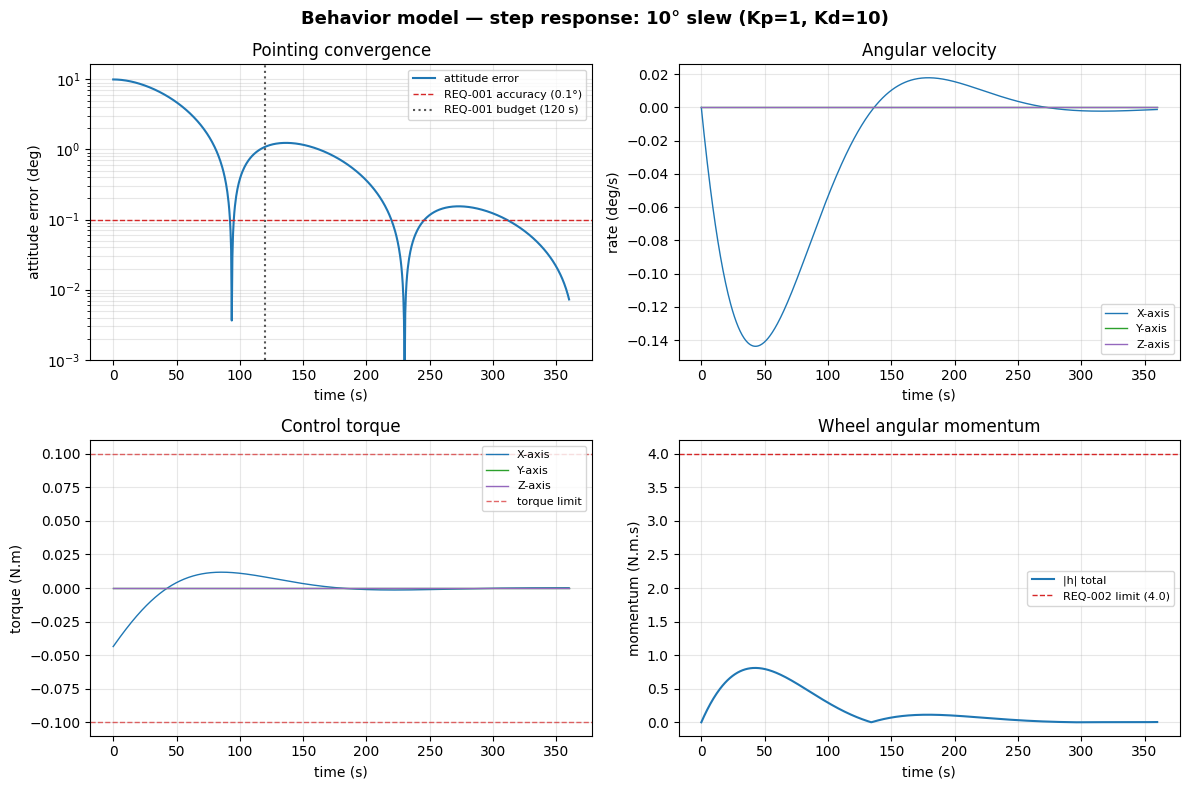

In [5]:
# Reused step-response figure (analysis already ran above). The dotted vertical
# line is REQ-001's 120 s settling budget — the oracle's acceptance criterion.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

theta_deg = np.degrees(2 * np.linalg.norm(sim.q[:, :3], axis=1))
axes[0, 0].semilogy(sim.t, theta_deg, color=AXIS_COLORS["X"], lw=1.5, label="attitude error")
axes[0, 0].axhline(0.1, color=LIMIT_COLOR, ls="--", lw=1, label="REQ-001 accuracy (0.1°)")
axes[0, 0].axvline(120, color="#555555", ls=":", lw=1.5, label="REQ-001 budget (120 s)")
axes[0, 0].set(xlabel="time (s)", ylabel="attitude error (deg)", title="Pointing convergence")
axes[0, 0].set_ylim(bottom=1e-3); axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3, which="both")

for i, (ax_name, c) in enumerate(AXIS_COLORS.items()):
    axes[0, 1].plot(sim.t, np.degrees(sim.omega[:, i]), color=c, lw=1, label=f"{ax_name}-axis")
axes[0, 1].set(xlabel="time (s)", ylabel="rate (deg/s)", title="Angular velocity")
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

for i, (ax_name, c) in enumerate(AXIS_COLORS.items()):
    axes[1, 0].plot(sim.t, sim.tau_ctrl[:, i], color=c, lw=1, label=f"{ax_name}-axis")
axes[1, 0].axhline(sim.config.max_torque, color=LIMIT_COLOR, ls="--", lw=1, alpha=0.7, label="torque limit")
axes[1, 0].axhline(-sim.config.max_torque, color=LIMIT_COLOR, ls="--", lw=1, alpha=0.7)
axes[1, 0].set(xlabel="time (s)", ylabel="torque (N.m)", title="Control torque")
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(sim.t, np.linalg.norm(sim.h_wheel, axis=1), color=AXIS_COLORS["X"], lw=1.5, label="|h| total")
axes[1, 1].axhline(sim.config.max_momentum, color=LIMIT_COLOR, ls="--", lw=1, label="REQ-002 limit (4.0)")
axes[1, 1].set(xlabel="time (s)", ylabel="momentum (N.m.s)", title="Wheel angular momentum")
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Behavior model — step response: 10° slew (Kp=1, Kd=10)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [6]:
from analysis.oracle import evaluate_requirement_oracle

# One merged metric dict the oracle reads from (numerical + symbolic).
metrics = dict(summary)
metrics["worst_real_part"] = worst_real_part

oracle_results = {req: evaluate_requirement_oracle(metrics, req)
                  for req in ("REQ-001", "REQ-002", "REQ-003", "REQ-004")}

# Render the model-level VERIFICATION outcomes as a colored table.
badge = {"passed": "#2EA84E", "failed": "#D94A4A", "cantTell": "#A6794D"}
rows = ""
for req, r in oracle_results.items():
    c = badge.get(r.outcome, "#888888")
    chip = (f"<span style='background:{c};color:white;padding:2px 8px;"
            f"border-radius:4px;font-family:monospace'>earl:{r.outcome}</span>")
    rows += (f"<tr><td><b>{req}</b></td><td>{chip}</td>"
             f"<td style='font-family:monospace;font-size:90%'>{r.detail}</td></tr>")
HTML(
    "<table style='border-collapse:collapse'>"
    "<thead><tr style='text-align:left;border-bottom:1px solid #ccc'>"
    "<th>requirement</th><th>oracle outcome</th><th>model-level comparison</th></tr></thead>"
    f"<tbody>{rows}</tbody></table>"
    "<p style='font-size:90%;color:#555'>REQ-004 has no machine-readable scalar "
    "budget &rarr; the oracle returns <b>cantTell</b> rather than fabricating a "
    "verdict it cannot compute.</p>"
)

requirement,oracle outcome,model-level comparison
REQ-001,earl:failed,settling_time_s = 310.626 le 120 s -> fail (model-level)
REQ-002,earl:passed,peak_wheel_momentum = 0.809768 le 4 N.m.s -> pass (model-level)
REQ-003,earl:passed,worst_real_part = -0.0152841 le -0.01 rad/s -> pass (model-level)
REQ-004,earl:cantTell,no machine-readable acceptance criterion for this requirement


In [7]:
from traceability.oracle_assertion import emit_oracle_assertion

# Persist the REQ-001 oracle outcome as an earl:Assertion and show the RDF.
demo = Dataset()
ev = URIRef("urn:adcs:evidence:EV-SIM-REQ-001")
emit_oracle_assertion(demo, ev, ADCS["REQ-001"], oracle_results["REQ-001"])
print(demo.graph(URIRef(G_AUDIT)).serialize(format="turtle"))

@prefix ns1: <http://www.w3.org/ns/earl#> .
@prefix ns2: <http://example.org/ontology/rtm#> .
@prefix prov: <http://www.w3.org/ns/prov#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<urn:adcs:assertion:oracle-REQ-001-2026-06-11T09-49-37-178068-00-00> a ns2:BehaviorOracleAssertion,
        ns1:Assertion,
        prov:Activity ;
    ns2:evaluatesAgainst <http://example.org/adcs-demo/REQ-001> ;
    ns2:metricKey "settling_time_s" ;
    ns2:metricValue 310.62618149585654 ;
    ns2:thresholdValue 120.0 ;
    ns1:mode ns1:automatic ;
    ns1:outcome ns1:failed ;
    ns1:subject <urn:adcs:evidence:EV-SIM-REQ-001> ;
    ns1:test <urn:adcs:test:behavior-oracle> ;
    prov:atTime "2026-06-11T09:49:37.178068+00:00"^^xsd:dateTime ;
    prov:wasAssociatedWith <urn:adcs:agent:behavior-oracle> .




Read the triples: `earl:subject` is the **evidence** under test; the
requirement is linked by `rtm:evaluatesAgainst` (subPropertyOf `prov:used`) —
**never** `rtm:attests`, which is reserved for the human. The oracle records
*what it computed*, not a judgment of satisfaction.

## 4 · The full lifecycle, then attestation = the human boundary

Now run the whole tested lifecycle locally. Watch the stage banners: assemble
ontology → load structural → symbolic → numerical → bind evidence → attest →
closure-rule verification → audit. It returns the populated `Dataset`.

In [8]:
from pipeline.runner import run_pipeline

ds = run_pipeline(auto_attest=True, backend="local")
print("\nlifecycle complete — Dataset populated")


[Preflight] Probing backends...
  Compute: Local in-process compute (host=Michaels-MacBook-Pro-2.local, python=3.12.12)
  Storage: Local filesystem (rdflib Dataset, persisted as output/rtm.ttl + output/rtm.trig)
  Compute probe: PASS
  Storage probe: PASS
  Operating org: urn:adcs:org:dynamical-systems-group (Dynamical Systems Group)
  Hosting org:   urn:adcs:org:planetary-utilities (Planetary Utilities)

[Stage 0/8] Ontology Assembly
──────────────────────────────────────────────────────────────────────────────
  Loading assembled rtm.ttl (built 2026-05-29T03:22:19Z from rtm-edit.ttl)
  Imports resolved:
    OK  EARL         162 triples,  5 terms referenced
    OK  OSLC QM       90 triples,  1 terms referenced
    OK  OSLC RM       74 triples,  1 terms referenced
    OK  OntoGSN     3784 triples,  3 terms referenced
    OK  P-PLAN       154 triples,  0 terms referenced
    OK  PROV-O      1146 triples,  10 terms referenced
  SysMLv2 equivalence axioms: 9
  Local rtm: integration glue

  Inertia: Jxx=327.1, Jyy=107.5, Jzz=303.4 kg.m^2
  Stability margins: x=-0.0153, y=-0.0465, z=-0.0165
  Proof REQ-001: VERIFIED (3 lemmas)
  Proof REQ-002: VERIFIED (3 lemmas)
  Proof REQ-003: VERIFIED (4 lemmas)
  Proof REQ-004: VERIFIED (3 lemmas)

[Stage 3] Running numerical simulations...
  Step response: settling=310.6s, final_error=0.0072 deg
  Peak wheel momentum: 0.810 N.m.s (limit: 4.0)
  Peak control torque: 0.0436 N.m (limit: 0.1)


  Disturbance rejection: peak_error=0.001000 deg

[Stage 4] Binding evidence to RDF graph...
  Evidence artifacts created: 135 nodes (written to <adcs:evidence>)

[Stage 5] Assembling RTM...
  Evidence completeness: PASS (all requirements have evidence)
  Pre-attestation RTM exported to output/rtm_pre_attestation.{ttl,trig}

[Stage 6] Human attestation...

  REQ-001: ATTESTATION DECLINED
    Settling time 311s exceeds 120s requirement.
    Action: retune gains (Kp: 1->4, Kd: 10->30) and re-verify.

  Requirement: REQ-001
  The ADCS shall maintain pointing accuracy within 0.1 degrees
        (3-sigma) under nominal disturbance conditions within 120 seconds
        of a slew maneuver.
  Derived from: SAT-REQ-POINTING
  Allocated to: PDController, StarTracker

  Evidence (2 artifacts):
    [ProofArtifact] hash=a7f1bfb5ca74cfae...
      Symbolic proof: Steady-state pointing error under constant disturbance is 2*tau_gg/Kp, bounded by actuator/gain design
    [SimulationResult] hash=068c61db


  REQ-003: outcome=earl:passed (ADCS Engineer)

  Requirement: REQ-004
  The ADCS shall reject gravity gradient disturbance torques
        encountered in geostationary orbit without exceeding actuator
        torque capacity.
  Derived from: SAT-REQ-DISTURBANCE
  Allocated to: PDController, ReactionWheel_X, ReactionWheel_Y, ReactionWheel_Z

  Evidence (2 artifacts):
    [ProofArtifact] hash=983c0d3b3d2e725c...
      Symbolic proof: Gravity gradient disturbance torque at GEO is orders of magnitude below reaction wheel torque capacity
    [SimulationResult] hash=d19e0be5468eddb0...
      Disturbance rejection: peak_error=0.001000 deg

  REQ-004: outcome=earl:passed (ADCS Engineer)

[Stage 6.5] Verifying closure-rule suite...


  Closure-rule verification: PASS
    SHACL shapes:        0 violations
    Re-verification:     0 mismatches
  Closure-rule assertion: urn:adcs:assertion:closure-2026-06-11T09-49-38-767563-00-00

[Stage 7a] Auditing forward / backward / bidirectional traceability...
  Forward    PASS  (4 checked, 0 failures)
  Backward   PASS  (4 checked, 0 failures)
  Bidirectional: PASS
  Orphans: none
  Audit report -> output/audit.md, output/audit.csv

[Stage 7] Generating reports...
  Backend: Local filesystem (rdflib Dataset, persisted as output/rtm.ttl + output/rtm.trig)
  Persisted 8 named graphs (1110 triples total)
REQUIREMENTS TRACEABILITY MATRIX — STATUS SUMMARY

  REQ-001: The ADCS shall maintain pointing accuracy within 0.1 degrees...
    Status: ATTESTED (earl:failed) — engineering finding

  REQ-002: Reaction wheel angular momentum shall not exceed the rated  ...
    Status: ATTESTED (earl:passed)

  REQ-003: The closed-loop ADCS shall be asymptotically stable with    ...
    Status: A

In [9]:
# Evidence binding (Stage 4): every artifact is content-addressed and
# addresses a requirement. (rtm:addresses = structural intent, NOT a verdict.)
q = '''
PREFIX rtm: <http://example.org/ontology/rtm#>
SELECT ?ev ?req ?hash ?summary WHERE {
  ?ev a rtm:SimulationResult ;
      rtm:addresses ?req ; rtm:contentHash ?hash ; rtm:resultSummary ?summary .
} ORDER BY ?req
'''
for row in ds.query(q):
    print(f"{str(row.req).split('/')[-1]}  hash={str(row.hash)[:16]}...")
    print(f"   {row.summary}\n")

REQ-001  hash=068c61dbfae35f13...
   Step response: settling=310.6s, final_error=0.0072 deg

REQ-002  hash=068c61dbfae35f13...
   Peak wheel momentum: 0.810 N.m.s (limit=4.0)

REQ-004  hash=d19e0be5468eddb0...
   Disturbance rejection: peak_error=0.001000 deg



The engineer attests each requirement with two distinct judgments — the
Hawkins–Habli Assurance Claim Point split:

- **model adequacy** (`gsn:Assumption`) — is the *model* a faithful enough
  representation of the physical system?
- **evidence sufficiency** (`gsn:Justification`) — given the model is adequate,
  does the evidence support the conclusion?

For REQ-001 the model-adequacy assumption **holds**; it is the evidence that
shows the requirement is **not yet satisfied**, so the requirement outcome is
`earl:failed` — **recorded, not hidden**. (The failure is the requirement
verdict, not a judgment that the model is inadequate.)

In [10]:
from collections import defaultdict

q = '''
PREFIX rtm: <http://example.org/ontology/rtm#>
PREFIX gsn: <https://w3id.org/OntoGSN/ontology#>
SELECT ?req ?outcome ?ctype ?stmt WHERE {
  ?a a rtm:Attestation ; rtm:attests ?req ; rtm:hasOutcome ?outcome ;
     gsn:inContextOf ?ctx .
  ?ctx a ?ctype ; gsn:statement ?stmt .
  FILTER(?ctype IN (gsn:Assumption, gsn:Justification))
} ORDER BY ?req
'''
ctx, outcome = defaultdict(dict), {}
for row in ds.query(q):
    req = str(row.req).split("/")[-1]
    outcome[req] = str(row.outcome).split("#")[-1]
    ctx[req][str(row.ctype).split("#")[-1]] = str(row.stmt)

label = {"Assumption": "model adequacy     (Assumption)",
         "Justification": "evidence sufficiency (Justification)"}
for req in sorted(ctx):
    print(f"{req}  -> requirement outcome: earl:{outcome[req]}")
    for kind in ("Assumption", "Justification"):
        if kind in ctx[req]:
            print(f"   {label[kind]}: {ctx[req][kind]}")
    print()

REQ-001  -> requirement outcome: earl:failed
   model adequacy     (Assumption): Rigid-body attitude dynamics with PD control and linearized gravity-gradient disturbance is an adequate representation of the GeoSat ADCS for assessing slew settling at this lifecycle stage. Flexible-mode and sensor-noise effects are second-order for this judgment.
   evidence sufficiency (Justification): Evidence is sufficient to conclude REQ-001 is NOT yet satisfied: settling time 311s exceeds the 120s requirement. Action item: retune gains (Kp: 1->4, Kd: 10->30) and re-verify.

REQ-002  -> requirement outcome: earl:passed
   model adequacy     (Assumption): Energy-based momentum bound is conservative. Reaction wheel model adequate for peak momentum estimation.
   evidence sufficiency (Justification): Symbolic bound and simulation both confirm peak momentum well below 4.0 N.m.s.

REQ-003  -> requirement outcome: earl:passed
   model adequacy     (Assumption): Linearized stability analysis via Routh-Hurwi

## 5 · The whole picture — bidirectional traceability

Fold the oracle outcomes into the lifecycle Dataset and render the entire RTM.
Every requirement traces **forward** to evidence and **backward** from
attestation. The attestation nodes are colored by `earl:outcome` — **REQ-001's
is red** (failed), in plain sight.

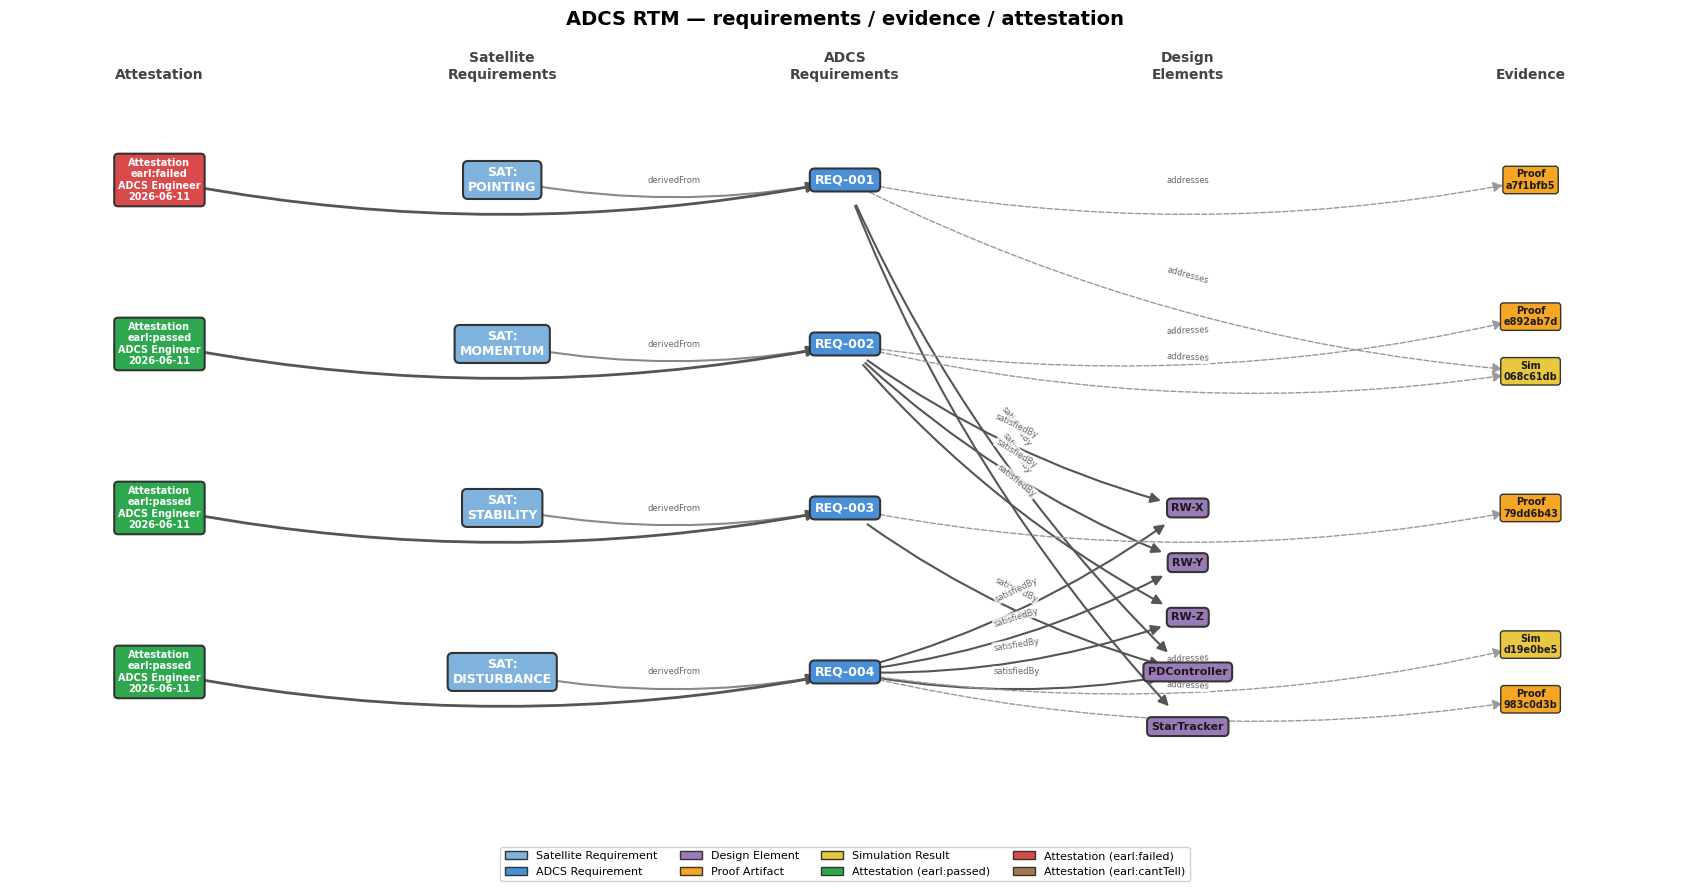

In [11]:
def evidence_for(ds, req):
    q = f'''
    PREFIX rtm: <http://example.org/ontology/rtm#>
    SELECT ?e WHERE {{ ?e rtm:addresses <{ADCS[req]}> }} LIMIT 1
    '''
    rows = list(ds.query(q))
    return rows[0].e if rows else URIRef(f"urn:adcs:evidence:{req}")

for req, r in oracle_results.items():
    emit_oracle_assertion(ds, evidence_for(ds, req), ADCS[req], r)

from interrogate.visualize import build_rtm_figure
build_rtm_figure(ds, figsize=(17, 9),
                 title="ADCS RTM — requirements / evidence / attestation")
plt.show()

## 6 · Provenance across distinct authoritative sources of truth  ·  *the point*

The same `Dataset` persists identically to local disk, **Flexo MMS**, or bare
Fuseki. No single store holds the whole truth — each is an authoritative source
under its own jurisdiction, stitched together by standard PROV edges:

```mermaid
graph LR
  subgraph git
    CODE[code · ontology · Dockerfile]
  end
  subgraph "local Docker"
    IMG[rtm:DockerImage] -->|prov:wasDerivedFrom| CON[rtm:DockerContainer]
  end
  subgraph "Flexo MMS"
    RDF[RDF named graphs · evidence · attestations · audit]
  end
  subgraph "txn-log store"
    LOG[wire-log JSON]
  end
  CON -->|prov:used| ACT[analysis activity]
  ACT -->|prov:wasGeneratedBy| EV[evidence node]
  IMG -.->|rtm:gitRef| CODE
  IMG -.->|rtm:flexoRecord| RDF
  EV --> RDF
  ACT -.-> LOG
```

We push to the **Planetary Utilities Flexo instance** live, then read it back to
prove it landed. A fail-fast `probe()` runs first; with no `FLEXO_TOKEN` we skip
the remote and demonstrate the identical trust queries against the local
Dataset.

In [12]:
import httpx
from pipeline.backends.flexo import FlexoBackend
from pipeline.backends.base import BackendUnavailable

flexo = FlexoBackend()
flexo_live = False

# A live push needs a credential, not just a reachable host (the HEAD probe
# is unauthenticated). Gate on FLEXO_TOKEN, then probe for reachability.
if not flexo.token:
    print("FLEXO_TOKEN not set — offline rehearsal mode.")
    print("Trust queries below run identically against the local Dataset.")
else:
    try:
        flexo.probe()
        flexo_live = True
        print(f"Flexo reachable: {flexo.describe()}")
    except BackendUnavailable as exc:
        print(f"Flexo unreachable ({exc}). Continuing with local trust queries.")

Flexo reachable: Flexo MMS at https://try-layer1.starforge.app (org=adcs-demo / repo=lifecycle; auth=pre-issued)


In [13]:
if flexo_live:
    try:
        counts = flexo.persist(ds, Path("output"))
        print("pushed named graphs to Flexo:")
        for graph_iri, n in counts.items():
            print(f"  {n:>5} triples  ->  {graph_iri}")
        print(f"\nstable record URI: {flexo.record_uri('attestations')}")
    except (BackendUnavailable, httpx.HTTPError) as exc:
        flexo_live = False
        print(f"live push failed ({exc}); falling back to local trust queries.")
else:
    print("(skipped live push — offline rehearsal)")

pushed named graphs to Flexo:
     89 triples  ->  http://example.org/adcs-demo/graph/attestations
    253 triples  ->  http://example.org/adcs-demo/graph/structural
    103 triples  ->  http://example.org/adcs-demo/graph/plan
     57 triples  ->  http://example.org/adcs-demo/graph/plan-execution
    135 triples  ->  http://example.org/adcs-demo/graph/evidence
     68 triples  ->  http://example.org/adcs-demo/graph/audit
    454 triples  ->  http://example.org/adcs-demo/graph/ontology
      6 triples  ->  http://example.org/adcs-demo/graph/context

stable record URI: urn:adcs:flexo:adcs-demo/lifecycle/cert-2026-06-12-001-attestations


In [14]:
if flexo_live:
    # Read the attestation back from Flexo to prove it round-tripped.
    sparql = '''
    PREFIX rtm: <http://example.org/ontology/rtm#>
    PREFIX adcs: <http://example.org/adcs-demo/>
    ASK { adcs:ATT-REQ-003 a rtm:Attestation }
    '''
    url = (f"{flexo.url}/orgs/{flexo.org}/repos/{flexo.repo}"
           f"/branches/{flexo.branch_prefix}attestations/query")
    r = httpx.post(url, headers={
        "Authorization": f"Bearer {flexo.token}",
        "Content-Type": "application/sparql-query",
        "Accept": "application/json",
    }, content=sparql, timeout=30.0)
    print(f"read-back ASK -> {r.json()}")
else:
    print("(skipped live read-back — no FLEXO_TOKEN)")

read-back ASK -> {'head': {}, 'boolean': True}


The **trust queries** answer "how can I trust this?" — backend-agnostic, they
walk evidence → activity → container → image → git ref, plus the auspices
(who operated and hosted the run). This is reproducible evidence with full
provenance.

In [15]:
from traceability.queries import trust_summary, render_trust_summary

ev_iri = str(ADCS["EV-SIM-REQ-001"])
print(render_trust_summary(trust_summary(ds, ev_iri)))

Trust panel for http://example.org/adcs-demo/EV-SIM-REQ-001
Technical provenance:
  activity:    http://example.org/adcs-demo/NS-REQ-001
  container:   - (id=-)
  image:       http://example.org/adcs-demo/EV-PROOF-REQ-001
  digest:      a7f1bfb5ca74cfae7e8891b5caecb67eab6104b1eb0f838ff14c13ee683b829f
  git ref:     -
  host:        urn:adcs:location:local:Michaels-MacBook-Pro-2.local
  executor:    http://example.org/adcs-demo/ScipyEngine
Auspices:
  operating:   -
  hosting:     Planetary Utilities
Closure-rule assertions: 1
  - outcome=http://www.w3.org/ns/earl#passed violations=0


## 7 · Close the loop  ·  *push the button*

REQ-001 failed. The engineer retunes the controller gains. The model changes,
so its hash changes — **every prior proof and simulation bound to the old model
is invalidated**. Re-run the behavior model and the oracle: settling drops below
the 120 s budget and the outcome flips to `passed`. The loop is auditable
because every step traces across the ASoTs — and the vendor-neutral spine is
what made that possible.

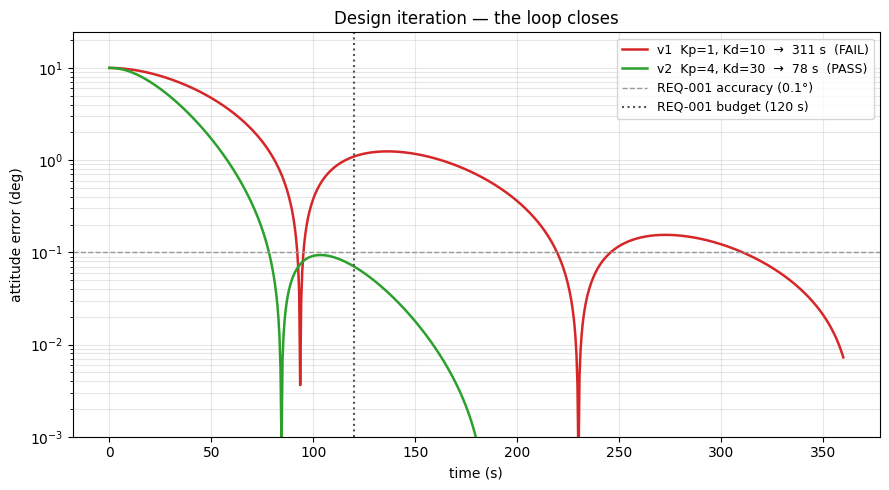

In [16]:
retuned = dict(params)
retuned["Kp"], retuned["Kd"] = 4.0, 30.0   # was 1.0 / 10.0

sim2 = run_step_response(retuned)
s2 = sim2.summary()
r2 = evaluate_requirement_oracle({**s2, "worst_real_part": worst_real_part}, "REQ-001")

# Before/after overlay of the attitude-error curve vs the 120 s budget.
theta_v1 = np.degrees(2 * np.linalg.norm(sim.q[:, :3], axis=1))
theta_v2 = np.degrees(2 * np.linalg.norm(sim2.q[:, :3], axis=1))

fig2, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(sim.t, theta_v1, color=LIMIT_COLOR, lw=1.8,
            label=f"v1  Kp=1, Kd=10  →  {summary['settling_time_s']:.0f} s  (FAIL)")
ax.semilogy(sim2.t, theta_v2, color=AXIS_COLORS["Y"], lw=1.8,
            label=f"v2  Kp=4, Kd=30  →  {s2['settling_time_s']:.0f} s  (PASS)")
ax.axhline(0.1, color="#999999", ls="--", lw=1, label="REQ-001 accuracy (0.1°)")
ax.axvline(120, color="#555555", ls=":", lw=1.5, label="REQ-001 budget (120 s)")
ax.set(xlabel="time (s)", ylabel="attitude error (deg)",
       title="Design iteration — the loop closes")
ax.set_ylim(bottom=1e-3); ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which="both")
fig2.tight_layout()
plt.show()

In [17]:
print(f"oracle re-verification:  earl:{r2.outcome}  —  {r2.detail}")
print("\nThe engineer would now re-attest REQ-001 against the v2 model.")
print("Evidence, oracle outcomes, and attestations all trace across git +")
print("Flexo + Docker. That is reproducible evidence with full provenance.")

oracle re-verification:  earl:passed  —  settling_time_s = 77.9662 le 120 s -> pass (model-level)

The engineer would now re-attest REQ-001 against the v2 model.
Evidence, oracle outcomes, and attestations all trace across git +
Flexo + Docker. That is reproducible evidence with full provenance.
